In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture

In [ ]:
# Step 1: Generate or Load a Dataset
# Here, we use a synthetic dataset for simplicity
X, y_true = make_blobs(n_samples=500, centers=3, cluster_std=1.8, random_state=42)
df = pd.DataFrame(X, columns=["Feature 1", "Feature 2"])
df

,Feature 1,Feature 2
0,-4.810935,-8.145827
1,-0.214517,1.875439
2,8.581524,0.518233
3,-3.214992,6.379959
4,6.802064,1.238634
...,...,...
495,-4.360787,-5.215769
496,-2.647981,9.628360
497,4.035466,4.977408
498,-7.820529,-4.991893


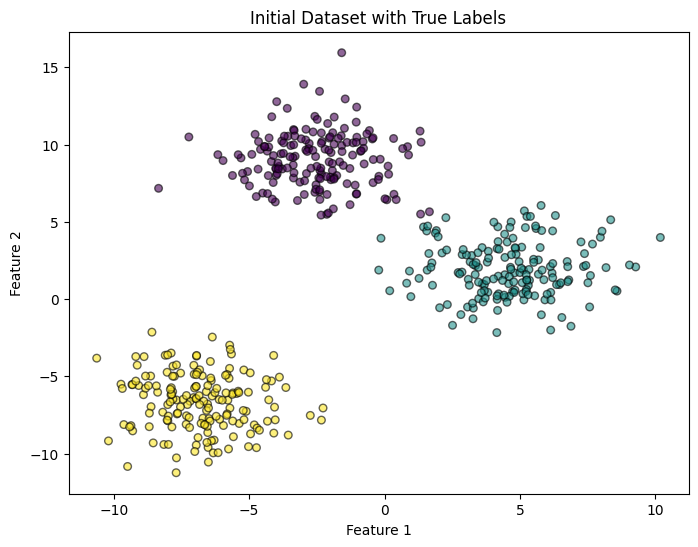

In [ ]:
# Step 2: Visualize the Data
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_true, s=30, cmap="viridis", alpha=0.6, edgecolor="k")
plt.title("Initial Dataset with True Labels")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [ ]:
# Step 3: Apply Gaussian Mixture Model
# We start by fitting a GMM with the number of components equal to the true clusters (4 in this case)
gmm = GaussianMixture(n_components=3, random_state=42)
gmm.fit(X)

# Analyze the GMM Model
print("GMM Model Details:")
print("Means:\n", gmm.means_)
print("\nConverged:", gmm.converged_)
print("\nNumber of Iterations:", gmm.n_iter_)

GMM Model Details:
Means:
 [[ 4.56335056  1.93706646]
 [-6.79245837 -6.6577482 ]
 [-2.55622539  9.08316998]]

Converged: True

Number of Iterations: 2


In [ ]:
# Step 4: Predict Cluster Memberships
labels = gmm.predict(X)
labels

array([1, 0, 0, 2, 0, 0, 1, 0, 0, 1, 0, 2, 0, 2, 0, 0, 2, 1, 1, 2, 0, 2,
       0, 1, 1, 0, 0, 1, 1, 2, 0, 2, 2, 2, 0, 0, 0, 0, 1, 1, 0, 2, 2, 2,
       2, 0, 0, 0, 0, 1, 1, 2, 1, 1, 0, 2, 2, 1, 0, 1, 1, 2, 0, 1, 0, 1,
       0, 1, 2, 0, 0, 0, 0, 1, 2, 1, 2, 0, 2, 2, 1, 2, 0, 2, 1, 1, 1, 1,
       0, 2, 1, 0, 2, 0, 0, 1, 2, 2, 2, 1, 0, 2, 2, 1, 1, 2, 2, 1, 2, 1,
       1, 1, 1, 1, 1, 0, 2, 1, 0, 1, 2, 2, 0, 0, 1, 0, 2, 0, 1, 1, 1, 0,
       0, 1, 0, 1, 1, 1, 0, 2, 1, 1, 0, 0, 1, 1, 1, 2, 2, 2, 0, 1, 0, 0,
       2, 1, 2, 1, 0, 0, 1, 1, 2, 2, 1, 2, 2, 0, 1, 1, 1, 2, 2, 1, 1, 2,
       2, 0, 0, 0, 2, 1, 2, 2, 1, 1, 2, 0, 2, 1, 1, 1, 1, 1, 2, 0, 2, 2,
       1, 0, 2, 2, 1, 1, 0, 1, 0, 2, 2, 1, 1, 0, 1, 2, 2, 1, 2, 1, 2, 0,
       0, 2, 1, 2, 0, 2, 2, 1, 0, 0, 0, 0, 2, 1, 1, 1, 2, 0, 2, 0, 0, 0,
       2, 2, 1, 1, 0, 2, 2, 0, 2, 2, 2, 2, 0, 2, 1, 2, 1, 2, 2, 2, 1, 2,
       0, 0, 0, 2, 0, 0, 2, 2, 0, 1, 2, 2, 2, 2, 1, 1, 2, 0, 2, 2, 1, 2,
       0, 1, 0, 0, 1, 2, 2, 2, 1, 2, 1, 0, 0, 2, 0,

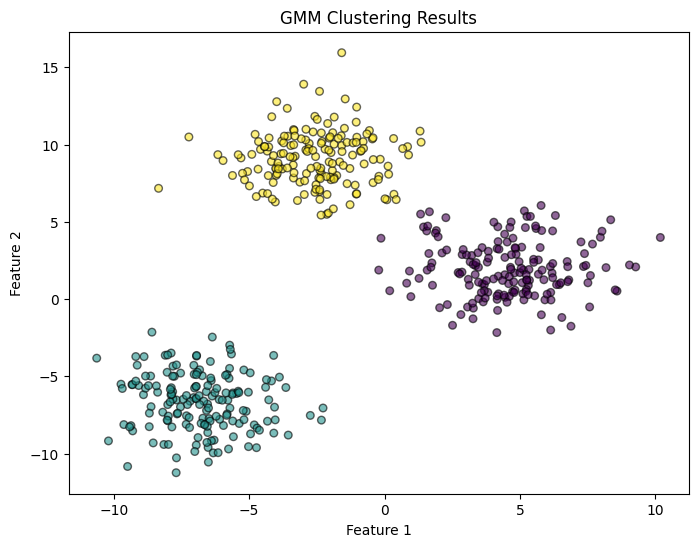

In [ ]:
# Step 5: Visualize the Clusters
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, s=30, cmap="viridis", alpha=0.6, edgecolor="k")
plt.title("GMM Clustering Results")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

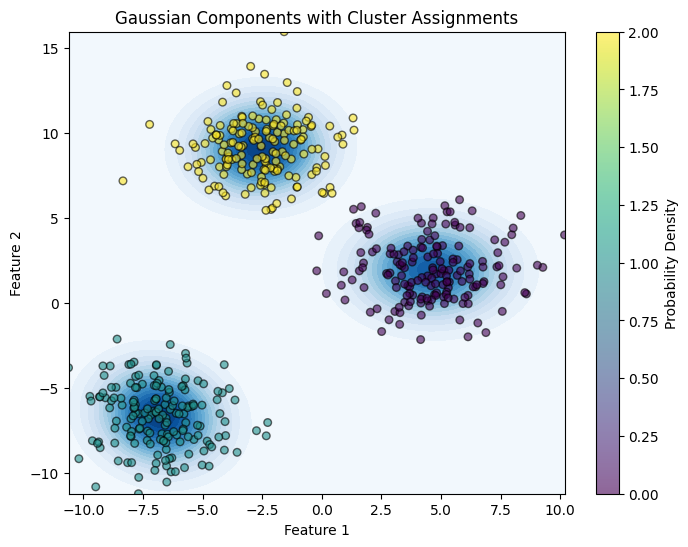

In [ ]:
# Step 6: Visualize the Gaussian Components
# Extract and plot the Gaussian components
plt.figure(figsize=(8, 6))
x, y = np.meshgrid(
    np.linspace(X[:, 0].min(), X[:, 0].max(), 100),
    np.linspace(X[:, 1].min(), X[:, 1].max(), 100),
)
XX = np.array([x.ravel(), y.ravel()]).T
probs = gmm.score_samples(XX)
probs = probs.reshape(100, 100)

plt.contourf(x, y, np.exp(probs), levels=20, cmap="Blues")
plt.scatter(X[:, 0], X[:, 1], c=labels, s=30, cmap="viridis", alpha=0.6, edgecolor="k")
plt.title("Gaussian Components with Cluster Assignments")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.colorbar(label="Probability Density")
plt.show()

In [ ]:
# Step 7: Evaluate the Model
sil_score = silhouette_score(X, labels)
print(f"Silhouette Score: {sil_score:.2f}")

Silhouette Score: 0.72


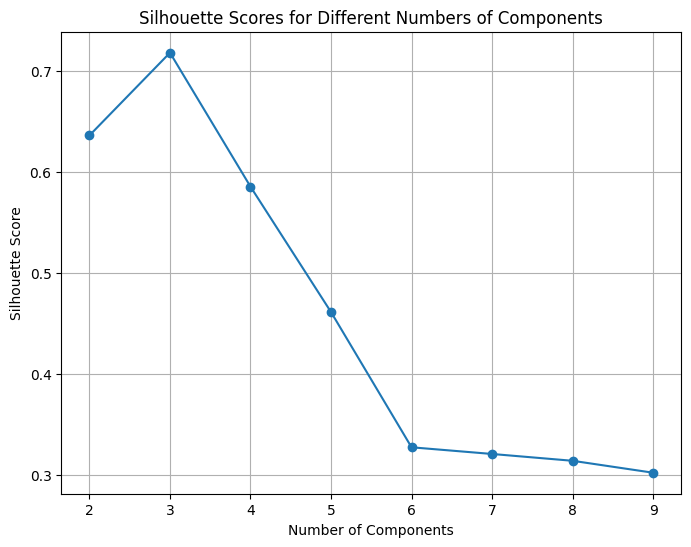

In [ ]:
# Step 8: Experiment with Different Numbers of Components
sil_scores = []
components = range(2, 10)

for n in components:
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(X)
    labels = gmm.predict(X)
    sil_scores.append(silhouette_score(X, labels))

# Plot Silhouette Scores
plt.figure(figsize=(8, 6))
plt.plot(components, sil_scores, marker="o")
plt.title("Silhouette Scores for Different Numbers of Components")
plt.xlabel("Number of Components")
plt.ylabel("Silhouette Score")
plt.grid()
plt.show()

Optimal number of components: 3


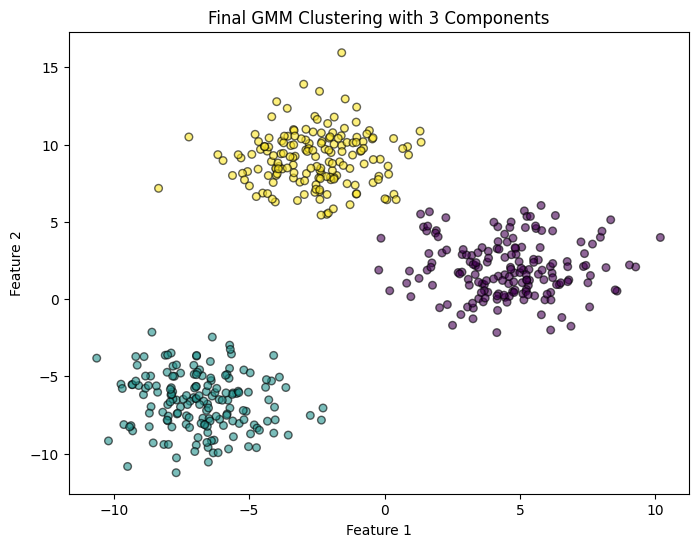

In [ ]:
# Step 9: Final Model with Optimal Components
optimal_components = components[np.argmax(sil_scores)]
print(f"Optimal number of components: {optimal_components}")
final_gmm = GaussianMixture(n_components=optimal_components, random_state=42)
final_gmm.fit(X)
final_labels = final_gmm.predict(X)

# Final Visualization
plt.figure(figsize=(8, 6))
plt.scatter(
    X[:, 0], X[:, 1], c=final_labels, s=30, cmap="viridis", alpha=0.6, edgecolor="k"
)
plt.title(f"Final GMM Clustering with {optimal_components} Components")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# Step 10: Explain Results
# Summary:
# - We used GMM to cluster the dataset into Gaussian components.
# - The silhouette score helped identify the optimal number of clusters.
# - Visualization highlighted the Gaussian components and their assignments.
# - GMM is flexible and models the data better when clusters have varying shapes or densities.
